In [9]:
import torch
import numpy as np
import anndata as ad
import pertpy
import scanpy as sc
import os
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

from data.space import SpaceManager
from data.dataset import CondFMDataset
from data.splitters import (
    SplitConfig,
    apply_holdout_masks,
    build_holdout_manifest,
    load_cell_names_csv,
    load_manifest_json,
    make_split_artifacts,
    save_cell_names_csv,
    save_manifest_json,
    select_subsample_cell_names,
    validate_no_leakage,
)
from models.flow import CondFlow, ConditionEncoder
from training.losses import LossComposer, OTLoss, DensityLoss, EnergyLoss
from training.trainer_neural_ode import train_neural_ode


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
config = SplitConfig()
artifacts = make_split_artifacts(config)

artifact_dir = artifacts.holdout_json_path.parent
artifact_dir.mkdir(parents=True, exist_ok=True)

subsample_h5ad_path = Path(f"sciplex_subsample_{artifacts.tag}.h5ad")
ode_model_path = Path(f"sciplex_ode_model_{artifacts.tag}.pt")
ode_metadata_path = Path(f"sciplex_ode_metadata_{artifacts.tag}.pkl")
space_path = Path(f"sciplex_space_{artifacts.tag}.pkl")

print(f"Using split tag: {artifacts.tag}")
print(f"Split artifacts dir: {artifact_dir}")

adata_full = pertpy.data.sciplex3_raw()

if artifacts.subsample_cells_csv_path.exists():
    subsample_cell_names = load_cell_names_csv(artifacts.subsample_cells_csv_path)
    print(f"Loaded {len(subsample_cell_names)} subsample cells from {artifacts.subsample_cells_csv_path}")
else:
    subsample_cell_names = select_subsample_cell_names(
        adata_full,
        n_cells=config.subsample_n_cells,
        seed=config.subsample_seed,
    )
    save_cell_names_csv(subsample_cell_names, artifacts.subsample_cells_csv_path)
    print(f"Saved {len(subsample_cell_names)} subsample cells to {artifacts.subsample_cells_csv_path}")

missing_cells = sorted(set(subsample_cell_names) - set(adata_full.obs_names))
if missing_cells:
    raise ValueError(
        f"{len(missing_cells)} subsample cells are missing from source AnnData. Example: {missing_cells[:5]}"
    )

adata = adata_full[subsample_cell_names].copy()
adata.write_h5ad(subsample_h5ad_path)
print(f"Wrote canonical subsample AnnData: {subsample_h5ad_path}")

space = SpaceManager(mode="log1p", n_hvgs=2000)
space.fit(adata)

if artifacts.holdout_json_path.exists():
    manifest = load_manifest_json(artifacts.holdout_json_path)
    print(f"Loaded holdout manifest: {artifacts.holdout_json_path}")
else:
    manifest = build_holdout_manifest(adata, config)
    save_manifest_json(manifest, artifacts.holdout_json_path)
    print(f"Saved holdout manifest: {artifacts.holdout_json_path}")


Using split tag: strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle
Split artifacts dir: artifacts/splits
Saved 100000 subsample cells to artifacts/splits/sciplex_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle_subsample_cells.csv
Wrote canonical subsample AnnData: sciplex_subsample_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.h5ad


/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(temp_adata, n_top_genes=self.n_hvgs, flavor="seurat_v3", subset=False)


Saved holdout manifest: artifacts/splits/sciplex_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle_holdout.json


In [12]:
SEED = config.seed
test_cell_type = config.test_cell_type

masks = apply_holdout_masks(adata, manifest)
validate_no_leakage(adata, masks, product_name_col="product_name")

is_held_out = masks["is_held_out"]
is_pert_any = masks["is_pert_any"]
is_pert_train = masks["is_pert_train"]
adata_train = adata[masks["is_train"]].copy()

held_out_products = manifest["selected_holdout_product_names"]
print(f"held-out products for {test_cell_type}: {held_out_products}")
print(
    f"Train cells: {masks['is_train'].sum()}, "
    f"Held-out perturbed cells: {is_held_out.sum()}, "
    f"Train perturbed cells: {is_pert_train.sum()}"
)


held-out products for K562: ['AG-490 (Tyrphostin B42)', 'AMG-900', 'AR-42', 'AZ 960', 'AZD1480', 'Alendronate sodium trihydrate', 'Alvespimycin (17-DMAG) HCl', 'Anacardic Acid', 'Andarine', 'Aurora A Inhibitor I', 'Avagacestat (BMS-708163)', 'BMS-911543', 'Baricitinib (LY3009104, INCB028050)', 'CEP-33779', 'CYC116', 'Cediranib (AZD2171)', 'Celecoxib', 'Crizotinib (PF-02341066)', 'Dacinostat (LAQ824)', 'Danusertib (PHA-739358)', 'Daphnetin', 'Dasatinib', 'Decitabine', 'Disulfiram ', 'Divalproex Sodium', 'ENMD-2076', 'Ellagic acid', 'Entacapone', 'Enzastaurin (LY317615)', 'FLLL32', 'Fedratinib (SAR302503, TG101348)', 'Filgotinib (GLPG0634)', 'Flavopiridol HCl', 'Fluorouracil (5-Fluoracil, 5-FU)', 'G007-LK', 'GSK-LSD1 2HCl', 'GSK1070916', 'Gandotinib (LY2784544)', 'Glesatinib?(MGCD265)', 'INO-1001 (3-Aminobenzamide)', 'ITSA-1 (ITSA1)', 'Iniparib (BSI-201)', 'Ivosidenib (AG-120)', 'Lenalidomide (CC-5013)', 'Linifanib (ABT-869)', 'Lomustine ', 'Luminespib (AUY-922, NVP-AUY922)', 'M344', 'MK

In [13]:
unique_perts = sorted(adata.obs["product_dose"].unique())
pert_to_idx = {p: i for i, p in enumerate(unique_perts)}

unique_reps = sorted(adata.obs["replicate"].unique())
rep_to_idx = {r: i for i, r in enumerate(unique_reps)}

unique_cts = sorted(adata.obs["cell_type"].unique())
ct_to_idx = {ct: i for i, ct in enumerate(unique_cts)}

pert_ids = torch.tensor([pert_to_idx[p] for p in adata_train.obs["product_dose"]], dtype=torch.long)
rep_ids = torch.tensor([rep_to_idx[r] for r in adata_train.obs["replicate"]], dtype=torch.long)
ct_ids = torch.tensor([ct_to_idx[ct] for ct in adata_train.obs["cell_type"]], dtype=torch.long)

condition_batch = {
    "perturbations": pert_ids,
    "perturbation_covariates": {},
    "sample_covariates": {
        "replicate": rep_ids,
        "cell_type": ct_ids,
    },
}

adata_train_hvg = adata_train[:, space.hvg_names].copy()
sc.pp.normalize_total(adata_train_hvg, target_sum=1e4)
sc.pp.log1p(adata_train_hvg)

ds = CondFMDataset(
    adata_train_hvg, condition_batch, control_col="vehicle", control_value=1.0, use_pca=False, use_norm=False
)

In [14]:
covariate_dicts = {
    "perturbation_num_categories": len(unique_perts),
    "perturbation_covariates": {},
    "sample_covariates": {"replicate": len(unique_reps), "cell_type": len(unique_cts)},
}

cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=64, condition_dim=128)
model = CondFlow(input_dim=2000, output_dim=2000, hidden_dim=256, hidden_layers=4, cond_encoder=cond_enc).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# using distribution matching
loss_composer = LossComposer(
    loss_map={"ot": OTLoss(), "density": DensityLoss(), "energy": EnergyLoss()},
    loss_weights={"ot": 1.0, "density": 0.1, "energy": 0.01},
)

history = train_neural_ode(
    model=model,
    dataset=ds,
    loss_composer=loss_composer,
    optimizer=optimizer,
    epochs=200,
    batch_size=2048,
    device=str(device),
    use_sampler=True,
    steps_per_epoch=50,
    ode_method="midpoint",
    adjoint=False,
    n_energy_steps=10,
)

torch.save(model.state_dict(), ode_model_path)

metadata = {
    "split_tag": artifacts.tag,
    "holdout_manifest_path": str(artifacts.holdout_json_path),
    "subsample_cells_csv_path": str(artifacts.subsample_cells_csv_path),
    "subsample_h5ad_path": str(subsample_h5ad_path),
    "pert_to_idx": pert_to_idx,
    "rep_to_idx": rep_to_idx,
    "ct_to_idx": ct_to_idx,
    "covariate_dicts": covariate_dicts,
    "hvg_names": space.hvg_names,
    "mean": ds.mean,
    "std": ds.std,
}
with open(ode_metadata_path, "wb") as f:
    pickle.dump(metadata, f)

with open(space_path, "wb") as f:
    pickle.dump(space, f)

print(f"Saved ODE model to {ode_model_path}")
print(f"Saved ODE metadata to {ode_metadata_path}")
print(f"Saved space manager to {space_path}")


training neural ODE model on device: cuda (adjoint=False, method=midpoint)


Epoch 1/200: 100%|██████████| 50/50 [00:03<00:00, 14.89it/s]


epoch 1/200 - train Loss: 4.3099


Epoch 2/200: 100%|██████████| 50/50 [00:03<00:00, 14.84it/s]


epoch 2/200 - train Loss: 3.6310


...

epoch 198/200 - train Loss: 3.2501


Epoch 199/200: 100%|██████████| 50/50 [00:03<00:00, 14.85it/s]


epoch 199/200 - train Loss: 3.1974


Epoch 200/200: 100%|██████████| 50/50 [00:03<00:00, 14.90it/s]

epoch 200/200 - train Loss: 3.1806
Saved ODE model to sciplex_ode_model_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pt
Saved ODE metadata to sciplex_ode_metadata_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pkl
Saved space manager to sciplex_space_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pkl


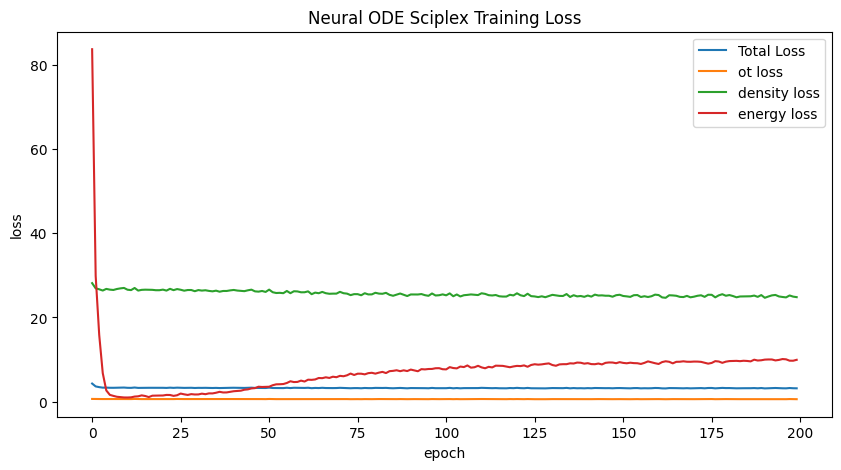

In [15]:
# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Total Loss")
for k, v in history["individual_train_losses"].items():
    plt.plot(v, label=f"{k} loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Neural ODE Sciplex Training Loss")
plt.legend()
plt.show()